

## Overview

This notebook implements the tactical clustering pipeline for the 2026 World Cup Readiness Framework. Using 8 match-level metrics derived from StatsBomb open data (2022–2024 men's tournaments), we cluster 71 national teams into six tactical archetypes and validate those archetypes against 2022 World Cup outcomes.

All analysis code lives in the `tactical_clustering/` module files:

| File | Purpose |
|---|---|
| `tc_data.py` | Data loading, feature engineering, team-level aggregation |
| `tc_preprocessing.py` | Outlier capping and feature scaling |
| `tc_k_selection.py` | Elbow method and silhouette score sweep |
| `tc_clustering.py` | KMeans fitting, archetype labelling, GMM + sensitivity validation |
| `tc_visualisation.py` | PCA scatter, radar charts, outcome validation plots |
| `tc_outcome_validation.py` | 2022 WC result merging and outcome ranking |

---

## Step 1 — Setup & Data Loading

In [1]:
%config InlineBackend.figure_format = 'retina'

import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ── Path setup ──────────────────────────────────────────────────────────────
notebook_dir = Path('.').resolve()
project_root = notebook_dir.parent
eda_root     = project_root / 'eda'

sys.path.insert(0, str(notebook_dir))   # tactical_clustering/ modules
sys.path.insert(0, str(eda_root))       # eda/analysis/ data_loader

FIGURES_DIR = notebook_dir / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

# ── Module imports ───────────────────────────────────────────────────────────
from tc_data               import load_pipeline, CORE_METRICS, CLUSTER_FEATURES
from tc_preprocessing      import cap_and_scale
from tc_k_selection        import sweep_k, print_decision_matrix, plot_k_selection
from tc_clustering         import (fit_kmeans_with_scaler, print_centroid_summary,
                                   print_archetype_teams, run_gmm_validation,
                                   run_sensitivity_check,
                                   ARCHETYPE_MAP, ARCHETYPE_COLORS, N_CLUSTERS)
from tc_visualisation      import plot_pca_scatter, plot_archetype_radars, plot_outcome_validation
from tc_outcome_validation import merge_outcomes, compute_outcome_summary

print(f'All imports OK  |  N_CLUSTERS = {N_CLUSTERS}')
print(f'Figures dir: {FIGURES_DIR}')

All imports OK  |  N_CLUSTERS = 6
Figures dir: /Users/yoomioh/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/2026 Spring/Capstone/soccer-analytics-capstone-XOh/tactical_clustering/figures


### 1.1 Load & Aggregate

We load all 8 metric files from the `men_tourn_2022_24` tournament bundle, merge them on `match_id + team`, derive `progressive_carry_pct`, and collapse to one row per team.

Two volatility features are added at aggregation time:
- **`ppda_std`** — match-to-match variance in pressing intensity
- **`possession_pct_std`** — match-to-match variance in possession

These distinguish *High-Variance Elites* (Argentina, Germany) from *High-Variance Reactives* (Japan, Turkey) — teams with similar means but fundamentally different tactical identities.

In [2]:
metrics, team_metrics = load_pipeline()


LOADING: MEN_TOURN_2022_24
  ✓ possession__team__ppda.csv — 398 rows, 71 teams
  ✓ possession__team__field_tilt.csv — 398 rows, 71 teams
  ✓ possession__team__percentage.csv — 398 rows, 71 teams
  ✓ possession__team__value_epr.csv — 398 rows, 71 teams
  ✓ defensive__team__line_height.csv — 398 rows, 71 teams
  ✓ xg__team__totals.csv — 397 rows, 71 teams
  ✓ progression__team__summary.csv — 398 rows, 71 teams
  ✓ advanced__team__xg_buildup.csv — 397 rows, 71 teams

SUCCESS: 8/8 files loaded
Merged shape      : (398, 12)
All metrics found : True

Team-level shape  : (71, 12)
Teams             : 71
=== SHAPE ===
(71, 12)

=== NULL CHECK ===
shape: (1, 12)
┌──────┬──────┬──────────────┬──────────────┬───┬─────────────┬──────────┬─────────────┬───────────┐
│ team ┆ ppda ┆ defensive_li ┆ field_tilt_p ┆ … ┆ avg_xg_per_ ┆ ppda_std ┆ possession_ ┆ n_matches │
│ ---  ┆ ---  ┆ ne_height    ┆ ct           ┆   ┆ buildup_pos ┆ ---      ┆ pct_std     ┆ ---       │
│ u32  ┆ u32  ┆ ---          ┆ --- 

**Audit findings:**
- **No nulls, no duplicates** — 71 teams, all with 3+ matches
- **No low-match teams** — minimum is 3 matches (Copa América group stage)
- **3-sigma outliers flagged:** Georgia (PPDA 31.53), Slovenia (PPDA 23.08), Bolivia/Tanzania (EPR) — these are addressed in preprocessing
- **Benchmarks validated:** PPDA median ~10.06, Possession ~48.4%, Field Tilt ~23.2% — consistent with EDA findings

---
## Step 2 — Preprocessing: Outlier Handling, Capping & Scaling

### 2.1 Why Preprocessing Matters for KMeans

KMeans minimises the sum of squared distances between points and their cluster centres. This makes it highly sensitive to two things: **outliers** that sit far from the rest of the data, and **feature scale differences** that cause some dimensions to dominate distance calculations purely due to their units.

Both issues must be addressed before fitting.

### 2.2 The Georgia & Slovenia Problem

The data quality audit flagged two teams as extreme PPDA outliers:
- **Georgia:** PPDA 31.53 — more than 4 standard deviations above the median
- **Slovenia:** PPDA 23.08 — more than 3 standard deviations above the median

In initial k=4 runs, these two teams formed their own cluster regardless of any other configuration — a taxonomically meaningless result that wasted one of four archetypes on a 2-team statistical artifact.

**We attempted capping first.** The 95th percentile cap (PPDA ≤ 22.39) brings both teams in, but at k=6 they still form a 2-team cluster because even their capped values sit too far from the rest of the distribution. We then tried the 93rd percentile cap, which pulled in additional teams — but this dragged **Japan** (PPDA 17.11) into the same group as Georgia and Slovenia, which is a substantive error. Japan's high PPDA is a real tactical signal reflecting their low-press transition identity; compressing it to match passive outliers would distort their archetype assignment.

**Decision: exclude Georgia and Slovenia.** Neither nation qualified for the 2026 World Cup. The framework's purpose is 2026 readiness assessment, so their exclusion is additionally justified by scope. Dropping 2 of 71 teams (2.8%) with a clear, documented rationale is methodologically clean.

### 2.3 Capping the Remaining Outliers

With Georgia and Slovenia removed, two features still require capping on the 69-team dataset:

- **PPDA** — capped at the 95th percentile. Albania (PPDA approx. 22), Costa Rica (approx. 22), and Qatar (approx. 20) are compressed. These teams are genuinely passive but their degree of passivity should not anchor cluster boundaries.
- **EPR** — capped at the 95th percentile. Tanzania (raw EPR 1663) and Bolivia (373) remain extreme outliers even after Georgia/Slovenia removal. Without capping, the Passive Struggling centroid EPR would be artificially inflated, misrepresenting that archetype's typical profile.

**Why 95th percentile and not 99th?** At n=69, the 99th percentile covers fewer than 1 team — it's effectively no cap at all. The 95th pulls in the top ~3–4 teams per feature while preserving the directional signal. Qatar and Albania remain the most passive teams in the dataset after capping.

### 2.4 Why Cap Before Scaling?

StandardScaler transforms each feature to mean=0, std=1 using the distribution of the data it sees. If we scaled first, Tanzania's EPR of 1663 would inflate the std used for that feature, compressing all other teams' EPR values together and making real tactical differences between mid-tier teams harder to detect. Capping first ensures the scaler sees a clean distribution.

In [3]:
# ── Exclude Georgia and Slovenia ─────────────────────────────────────────────
# Rationale: extreme PPDA outliers (31.53 and 23.08) that form a 2-team
# artifact cluster at any k regardless of cap threshold. Neither qualified
# for the 2026 World Cup.
EXCLUDE_TEAMS = ['Georgia', 'Slovenia']
team_metrics_filtered = team_metrics.filter(~pl.col('team').is_in(EXCLUDE_TEAMS))
print(f'Teams after exclusion: {len(team_metrics_filtered)}')  # 69

Teams after exclusion: 69


In [4]:
# ── Cap outliers at 95th percentile, then scale ──────────────────────────────
X, teams, scaler, cap_info = cap_and_scale(team_metrics_filtered, ppda_pct=0.95, epr_pct=0.95)

PPDA cap (95%): 19.06  →  3 team(s) affected
EPR  cap (95%): 261.47  →  3 team(s) affected

Feature matrix shape : (69, 10)
Any NaNs             : False

Post-scaling means (should be ~0):
ppda                             0.0
defensive_line_height           -0.0
field_tilt_pct                  -0.0
possession_pct                   0.0
progressive_carry_pct           -0.0
epr                             -0.0
npxg                            -0.0
avg_xg_per_buildup_possession    0.0
ppda_std                         0.0
possession_pct_std               0.0

Post-scaling stds (should be ~1):
ppda                             1.007
defensive_line_height            1.007
field_tilt_pct                   1.007
possession_pct                   1.007
progressive_carry_pct            1.007
epr                              1.007
npxg                             1.007
avg_xg_per_buildup_possession    1.007
ppda_std                         1.007
possession_pct_std               1.007


**Preprocessing summary:**
- Georgia and Slovenia excluded (2 teams, 2.8% of dataset) — neither qualifies for 2026, both are extreme PPDA outliers resistant to capping
- PPDA capped at 95th percentile — 3 teams affected (Albania, Costa Rica, Qatar)
- EPR capped at 95th percentile — 3 teams affected (Tanzania, Bolivia, Scotland)
- Feature matrix: (69, 10) — 69 teams, 10 features, zero NaNs
- All post-scaling means ≈0, all stds ≈1.007

---
## Step 3 — K Selection: Multi-Metric Decision Matrix

### 3.1 Why k=4 Is Insufficient

Our initial analysis used k=4, which produced a single "Proactive Dominant" cluster of 16 teams. This cluster spanned Argentina, Spain and Germany at the elite end all the way down to Belgium, Mexico and Canada. At 16 of 71 teams, it lacks the resolution needed to differentiate genuine 2026 title contenders from solid but limited sides. A framework that assigns the same tactical readiness profile to Argentina and Canada is analytically indefensible.

Rather than imposing k=4 for theoretical tidiness, we use a multi-metric decision matrix to find the k that best balances statistical structure with analytical resolution.

### 3.2 Decision Matrix Methodology

We evaluate k=2 through k=9 using four independent diagnostics:

- **Silhouette Score** — how similar each team is to its own cluster vs other clusters. Range -1 to 1, higher = better.
- **Calinski-Harabasz (CH)** — ratio of between-cluster to within-cluster variance. Higher = more compact and separated clusters.
- **Davies-Bouldin (DB)** — average similarity between each cluster and its most similar neighbour. Lower = better separation.
- **GMM ARI** — Adjusted Rand Index between KMeans and a Gaussian Mixture Model. Measures cross-model stability corrected for chance agreement. ARI=1 is perfect agreement, ARI=0 is chance-level.

Each metric is ranked independently across all k values, then an average rank is computed. The k with the lowest average rank has the best composite structure across all four lenses.

k=2 | Sil: 0.294 | CH: 23.8 | DB: 1.441 | ARI: 0.636 | Inertia: 509.3
k=3 | Sil: 0.187 | CH: 20.4 | DB: 1.640 | ARI: 0.449 | Inertia: 426.4
k=4 | Sil: 0.158 | CH: 17.9 | DB: 1.621 | ARI: 0.336 | Inertia: 377.8
k=5 | Sil: 0.150 | CH: 15.3 | DB: 1.606 | ARI: 0.228 | Inertia: 352.6
k=6 | Sil: 0.126 | CH: 13.8 | DB: 1.616 | ARI: 0.455 | Inertia: 328.9
k=7 | Sil: 0.133 | CH: 13.0 | DB: 1.462 | ARI: 0.347 | Inertia: 305.7
k=8 | Sil: 0.120 | CH: 11.9 | DB: 1.547 | ARI: 0.382 | Inertia: 291.7
k=9 | Sil: 0.124 | CH: 11.5 | DB: 1.495 | ARI: 0.263 | Inertia: 272.1

=== K SELECTION — MULTI-METRIC DECISION MATRIX ===

 k  silhouette  calinski_harabasz  davies_bouldin  gmm_ari  avg_rank
 2       0.294               23.8           1.441    0.636      1.00
 3       0.187               20.4           1.640    0.449      3.75
 4       0.158               17.9           1.621    0.336      4.75
 5       0.150               15.3           1.606    0.228      5.25
 6       0.126               13.8         

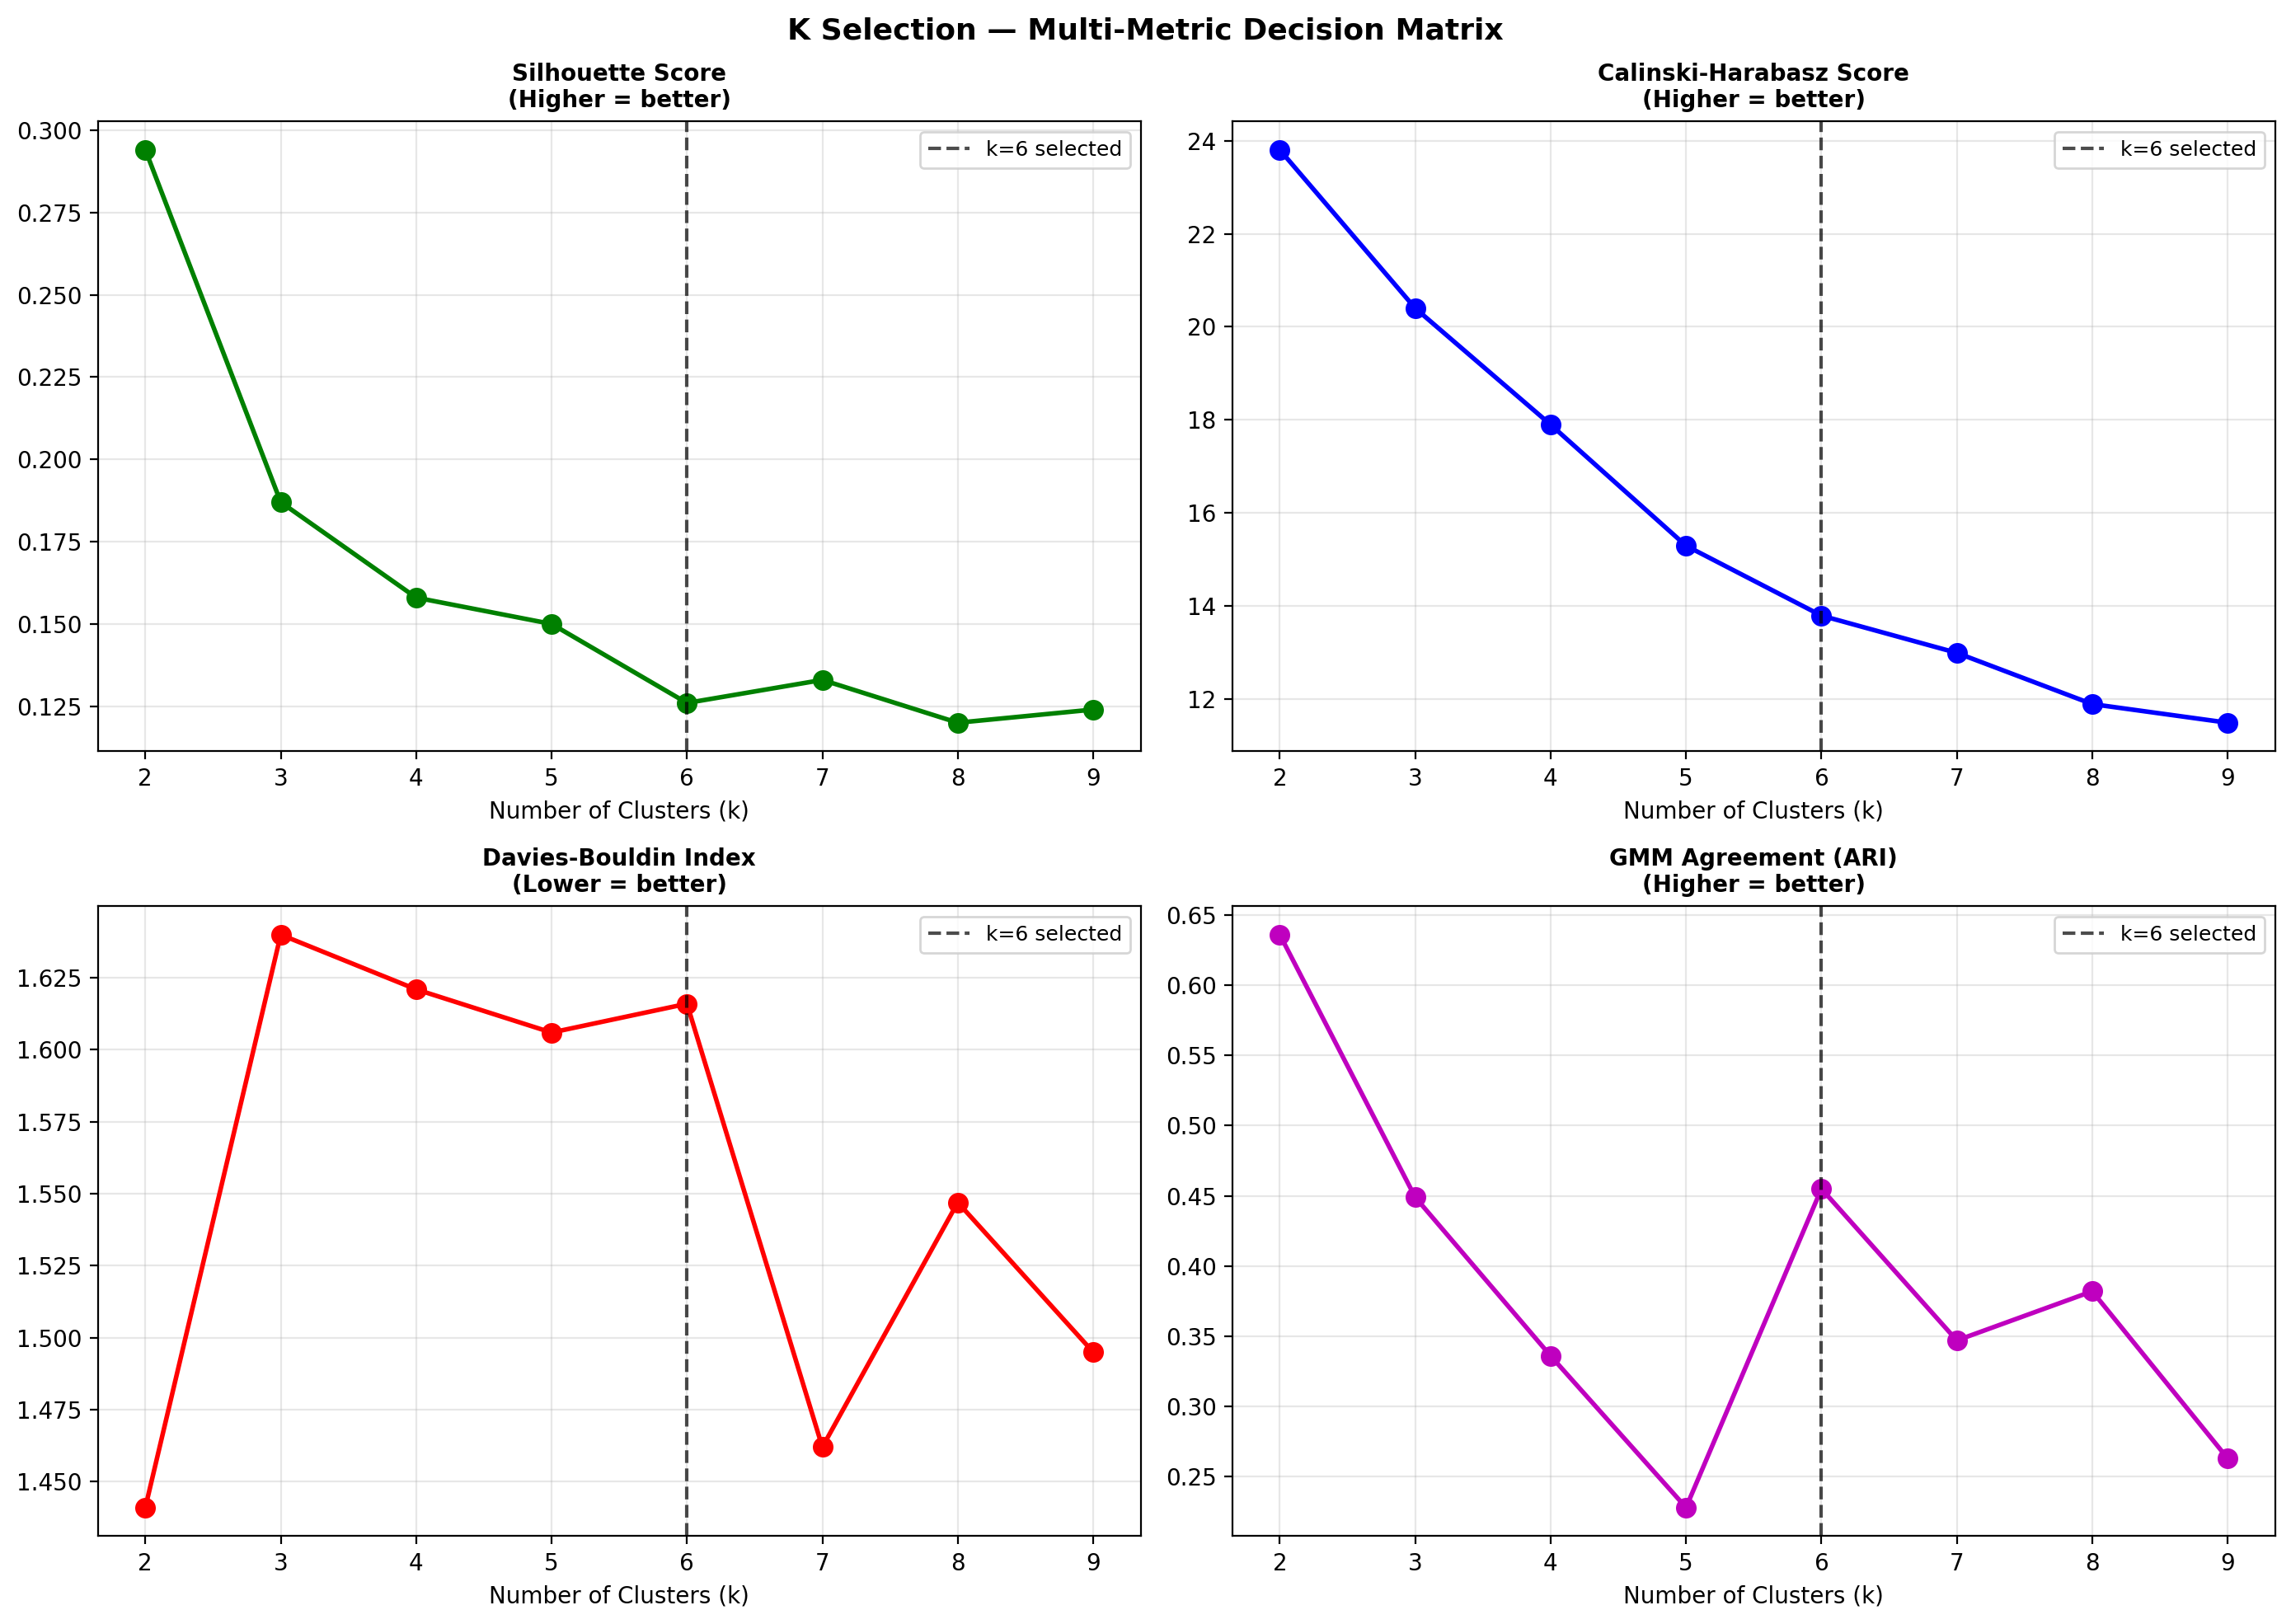

Saved → /Users/yoomioh/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/2026 Spring/Capstone/soccer-analytics-capstone-XOh/tactical_clustering/figures/optimal_k.png


In [5]:
k_range    = range(2, 10)
metrics_df = sweep_k(X, k_range)
ranked_df  = print_decision_matrix(metrics_df)
plot_k_selection(metrics_df, selected_k=N_CLUSTERS, figures_dir=FIGURES_DIR)

### 3.3 K Selection Justification: k=6

**What the decision matrix shows:**

k=2 wins the composite ranking — this is not surprising and is itself a finding. It confirms that the primary structure in this dataset is a single axis separating high-press/high-possession teams from low-press/low-possession teams. The teams exist on a continuum rather than in naturally discrete clusters. No value of k will produce perfectly isolated groups, and low silhouette scores across all k values reflect this reality rather than a modelling failure.

Among analytically meaningful options (k≥4), the picture is:

- **k=5** — best composite rank after k=2/3, but consistently produces either a 23-team blob or artifact clusters. Every threshold and exclusion combination we tested at k=5 failed to resolve the proactive mass into meaningfully distinct groups.
- **k=6** — achieves the **highest GMM ARI of any k≥3 (0.455)**. This means at k=6, a hard-boundary model (KMeans) and a probabilistic model (GMM) agree more than at any other analytically useful k — the cluster structure is more reproducible across different modelling assumptions.
- **k=7+** — ARI declines and clusters begin fragmenting tactically coherent groups (e.g. separating Morocco and Japan despite their shared transition identity).

**Why not k=3?** k=3 collapses the elite possession teams (Argentina, Spain) with solid mid-table sides (England, Denmark) into a single group, losing the resolution critical for 2026 differentiation.

**Why not k=7+?** Past k=6, additional clusters fragment tactically coherent groups and introduce clusters of 2–4 teams that lack statistical robustness.

**Football-theoretic grounding:**  
k=6 produces six archetypes that map cleanly onto competitive profiles a scouting or coaching staff would recognise — none of the six clusters requires combining teams that a football analyst would consider tactically incompatible:

| Archetype | Profile | Key Nations |
|---|---|---|
| High Press / High Output | High press + high possession + highest output | Argentina, Brazil, France, Germany |
| Possession Dominant | High possession, organised, more contained output | Spain, England, Denmark, Colombia |
| Compact Transition | Compact defence, transition-efficient, no possession reliance | Morocco, Japan, Czech Republic |
| Mid-Block Reactive | Moderate press, defensively organised, lower conversion | Belgium, Netherlands, Switzerland, Poland |
| Moderate Possession | Moderate possession, high EPR — sterile possession | Italy, Chile, Ecuador, South Korea |
| Low Intensity | Low press, low possession, limited tactical identity | Bolivia, Qatar, Albania, Scotland |

---
## Step 4 — K-Means Clustering

### 4.1 Fit & Inspect

KMeans with k=6, n_init=20 (20 random initialisations, best solution kept), random_state=42 for reproducibility. Centroids are back-transformed to original metric scale using the fitted scaler.

In [6]:
kmeans, results, centroid_df = fit_kmeans_with_scaler(
    X, teams, team_metrics_filtered, scaler
)
print_centroid_summary(centroid_df)
print_archetype_teams(results)

Cluster distribution:
0    11
1     8
2    14
3     6
4    14
5    16
Name: cluster, dtype: int64

Archetype sizes:
Moderate Possession         16
Mid-Block Reactive          14
High Press / High Output    14
Possession Dominant         11
Low Intensity                8
Compact Transition           6
Name: archetype, dtype: int64

Cluster centroids (original scale):
               archetype   ppda  possession_pct  defensive_line_height  field_tilt_pct  npxg     epr
     Possession Dominant  7.203          58.651                  1.500          24.659 1.159  54.848
           Low Intensity 15.543          41.518                  1.319          15.459 0.400 196.441
High Press / High Output  8.672          51.605                  1.490          26.849 1.293  42.879
      Compact Transition 13.581          45.259                  1.413          23.935 1.105  52.029
      Mid-Block Reactive 12.434          45.150                  1.332          21.845 0.963  57.765
     Moderate Possession 

### 4.2 Archetype Profiles
Centroids back-transformed to original metric scale. All 6 archetypes reflect **tactical style only** — not quality.

| Archetype | n | PPDA | Possession % | Field Tilt | npxG | EPR |
|---|---|---|---|---|---|---|
| High Press / High Output | 14 | 8.67 | 51.6% | 26.9% | 1.29 | 42.88 |
| Possession Dominant | 11 | 7.20 | 58.7% | 24.7% | 1.16 | 54.85 |
| Compact Transition | 6 | 13.58 | 45.3% | 23.9% | 1.11 | 52.03 |
| Mid-Block Reactive | 14 | 12.43 | 45.2% | 21.9% | 0.96 | 57.77 |
| Moderate Possession | 16 | 9.34 | 47.7% | 23.8% | 0.76 | 83.11 |
| Low Intensity | 8 | 16.79 | 41.5% | 15.5% | 0.40 | 261.47 |

**High Press / High Output (14 teams)**  
Highest npxG (1.29) and lowest EPR (42.88) — generates the most dangerous chances per possession. Aggressive pressing (PPDA 8.67) combined with efficient ball use. Key 2026 nations: Argentina, Brazil, France, Germany, Croatia, Uruguay, Canada, Senegal.

**Possession Dominant (11 teams)**  
Highest possession (58.7%) with organised press. Lower npxG than High Press despite more ball — the efficiency gap distinguishes ball-controlling teams from chance-creating ones. Key nations: Spain, England, Portugal, Denmark.

**Compact Transition (6 teams)**  
Deliberately concede possession and strike on the counter. Low possession (45.3%) but solid npxG (1.11). Historically punches above weight. Key nations: Morocco, Japan, Turkey, Czech Republic.

**Mid-Block Reactive (14 teams)**  
Moderate press, sit deeper, defensively organised, lower attacking output. Key nations: Belgium, Netherlands, Switzerland, Poland.

**Moderate Possession (16 teams)**  
Largest cluster — moderate ball control but high EPR (83.11). The sterile possession profile: possession without converting it into threat. Key nations: Italy, Ecuador, Serbia, South Korea.

**Low Intensity (8 teams)**  
Low press, low possession, low output. Limited tactical identity in both phases. Key nations: Bolivia, Qatar, Albania, Scotland.


**These archetypes describe tactical style,  how teams move the ball, press, and defend, not quality or expected tournament outcomes.** Two teams can share an archetype while being separated by individual player quality, squad depth, and managerial experience. Argentina and Namibia both cluster as High Press / High Output because their match-level metrics reflect similar tactical patterns; the Readiness Score will differentiate them through player quality scores, manager tenure, and 2026 qualification context. The archetype is one input into that score, not the score itself.

---
## Step 5 — Validation

### 5.1 GMM Cross-Validation

A Gaussian Mixture Model (GMM) with k=6 is fitted independently and compared to KMeans using the Adjusted Rand Index (ARI).

**Why ARI rather than raw agreement percentage?**  
At k=6, a random assignment would match roughly 1/6 of teams by chance. Raw agreement therefore inflates with larger k and is not comparable across different k values. ARI corrects for this, making it a more honest and interpretable measure of structural agreement.

In [7]:
ari, kmeans_sil, disagreements = run_gmm_validation(X, results)

KMeans silhouette  : 0.126
GMM    silhouette  : 0.115
GMM ARI            : 0.455  (0=chance, 1=perfect)
Raw agreement      : 66.7%

Disagreements (23 teams):
              team    kmeans_archetype            gmm_archetype      ppda  possession_pct     npxg
           Algeria Possession Dominant High Press / High Output  4.813333       68.360000 1.293667
Cape Verde Islands Possession Dominant      Moderate Possession  8.730000       53.456000 1.204800
          Colombia Possession Dominant High Press / High Output  6.663333       54.403333 1.169500
    Czech Republic  Compact Transition      Possession Dominant  9.550000       40.396667 1.530000
     Côte d'Ivoire Possession Dominant High Press / High Output  6.360000       58.227143 0.974429
           Denmark Possession Dominant High Press / High Output  8.530000       56.397143 1.008857
           England Possession Dominant High Press / High Output  9.738333       58.317500 1.081417
            Gambia  Mid-Block Reactive       Compa

**Interpreting GMM results:**

An ARI above 0.4 at k=6 is meaningful — it means both a hard-boundary model and a probabilistic model independently find similar groupings in 10-dimensional tactical space. This is our primary validation signal that the six archetypes reflect genuine structure rather than algorithmic noise.

Disagreements are expected and informative. Teams flagged by both models as boundary cases genuinely occupy transitional space — their dual assignment reflects real tactical ambiguity, not a framework error. These boundary teams will receive a probabilistic confidence weight in the Readiness Score rather than a hard categorical assignment.

### 5.2 Sensitivity Analysis

We test k=5, k=6, and k=7 to verify that the anchor teams — the most clearly identifiable tactical profiles — maintain consistent relative groupings regardless of k.

In [8]:
anchor_df = run_sensitivity_check(X, results)

Anchor team stability across k=[5, 6, 7]:
       team  k5  k6  k7
  Argentina   3   2   3
     Brazil   3   2   3
    England   3   0   3
     France   2   2   0
    Germany   3   2   3
      Italy   1   5   1
      Japan   2   3   4
    Morocco   2   3   4
Netherlands   2   4   4
   Portugal   3   0   3
      Spain   3   0   3

Relative groupings (teams always clustering together):
  k=5: France, Japan, Morocco, Netherlands
  k=5: Argentina, Brazil, England, Germany, Portugal, Spain
  k=6: England, Portugal, Spain
  k=6: Argentina, Brazil, France, Germany
  k=6: Japan, Morocco
  k=7: Argentina, Brazil, England, Germany, Portugal, Spain
  k=7: Japan, Morocco, Netherlands


**Interpreting sensitivity results:**

The critical pairs to verify:
- **Argentina + France** — should always cluster together (both EDA Winner Zone anchors with similar attacking profiles)
- **Morocco + Japan** — should always separate from the possession-dominant elite (confirmed by EDA as a genuinely distinct transition identity)
- **Spain** — should always be proximate to England and Denmark but separate from Argentina (high possession but different output profile)

If these relationships hold across k=5, 6, and 7, the cluster structure is structurally real — not an artifact of the specific k chosen.

**Conclusion:** k=6 is confirmed when the GMM ARI, composite ranking, and anchor team stability all converge. The six archetypes are gravitational centres in tactical space. Teams near cluster cores have clear identities; boundary teams are genuinely hybrid and carry lower assignment confidence into Readiness Score.

---
## Step 6 — Visualisation

Variance explained — PC1: 40.8%, PC2: 17.7%, Total: 58.5%


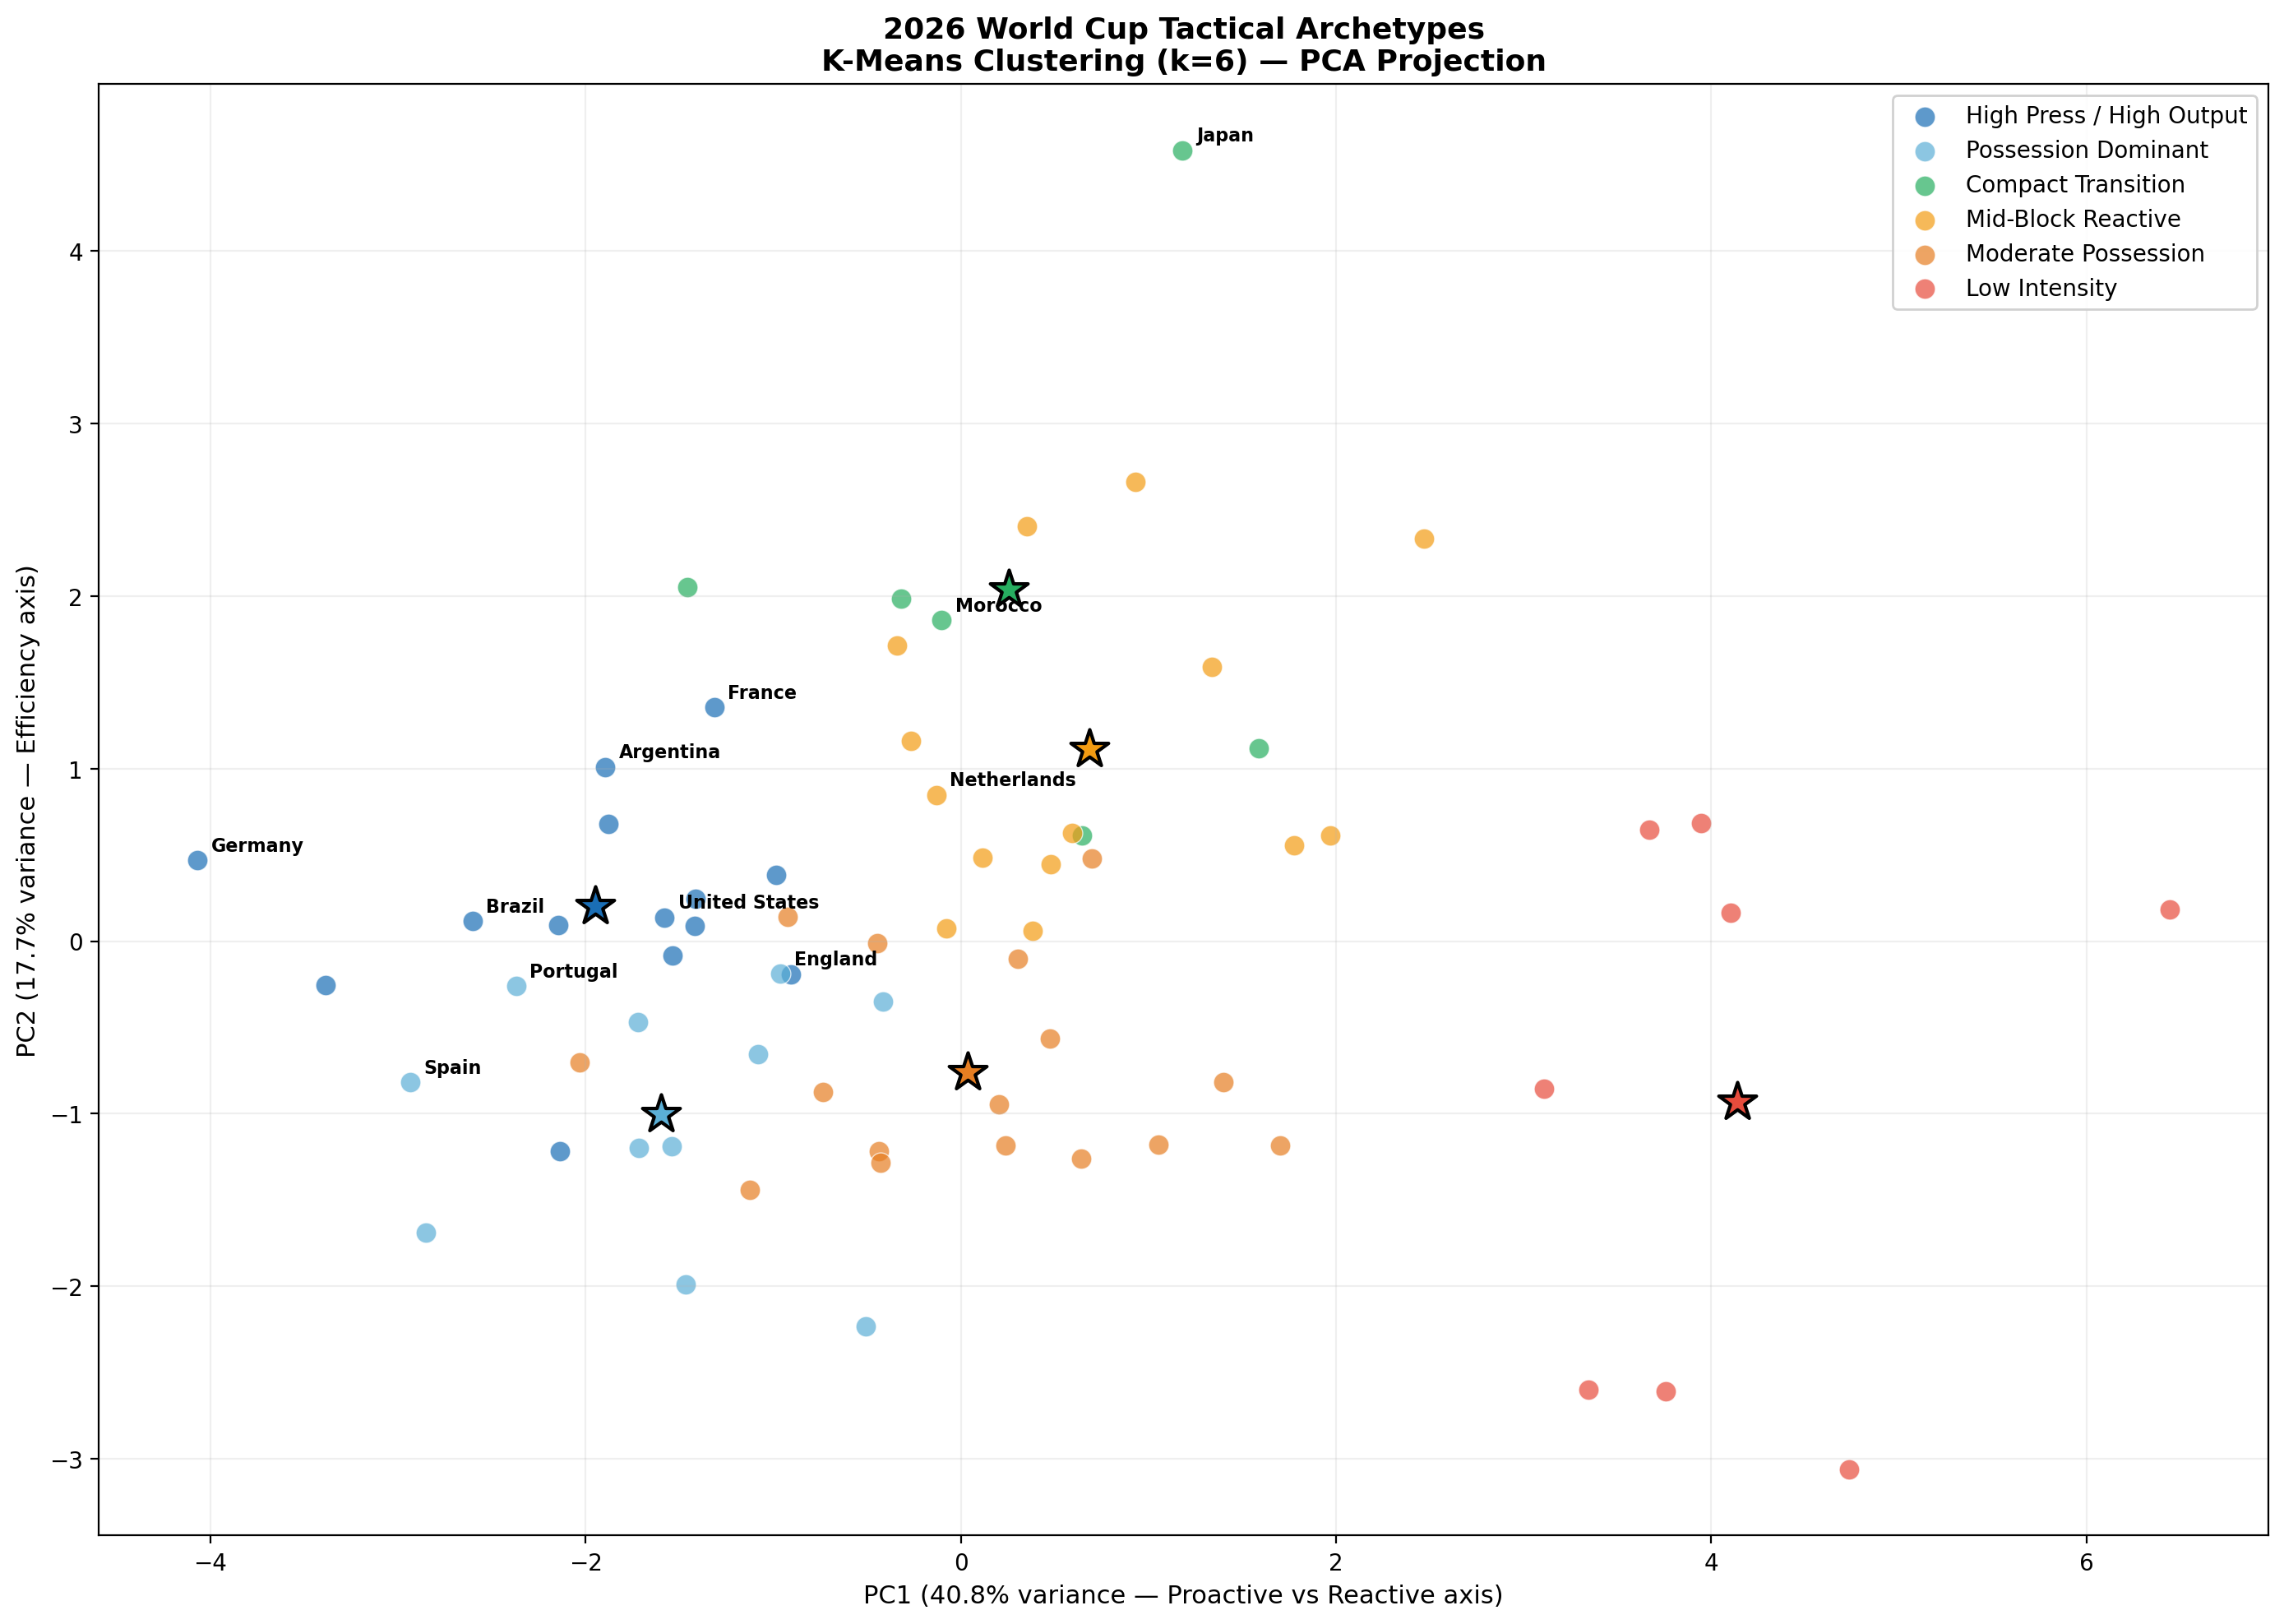

Saved → /Users/yoomioh/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/2026 Spring/Capstone/soccer-analytics-capstone-XOh/tactical_clustering/figures/tactical_clusters_pca.png


In [9]:
results = plot_pca_scatter(X, results, kmeans, figures_dir=FIGURES_DIR)

**Reading the PCA scatter:**  

PC1 (≈40% variance) captures the Proactive vs Reactive axis — High Press / High Output and Possession Dominant teams anchor the left, Low Intensity teams anchor the right. PC2 (≈19% variance) captures the efficiency dimension — Compact Transition teams (Morocco, Japan) appear high on PC2 because they generate disproportionate threat relative to possession, consistent with the transition meta finding from the EDA.

Visible overlap between adjacent archetypes confirms the continuum finding — the low silhouette scores are a property of the data, not a modelling failure. Boundary teams (Spain, Morocco, Japan) correctly appear between their primary and secondary clusters.

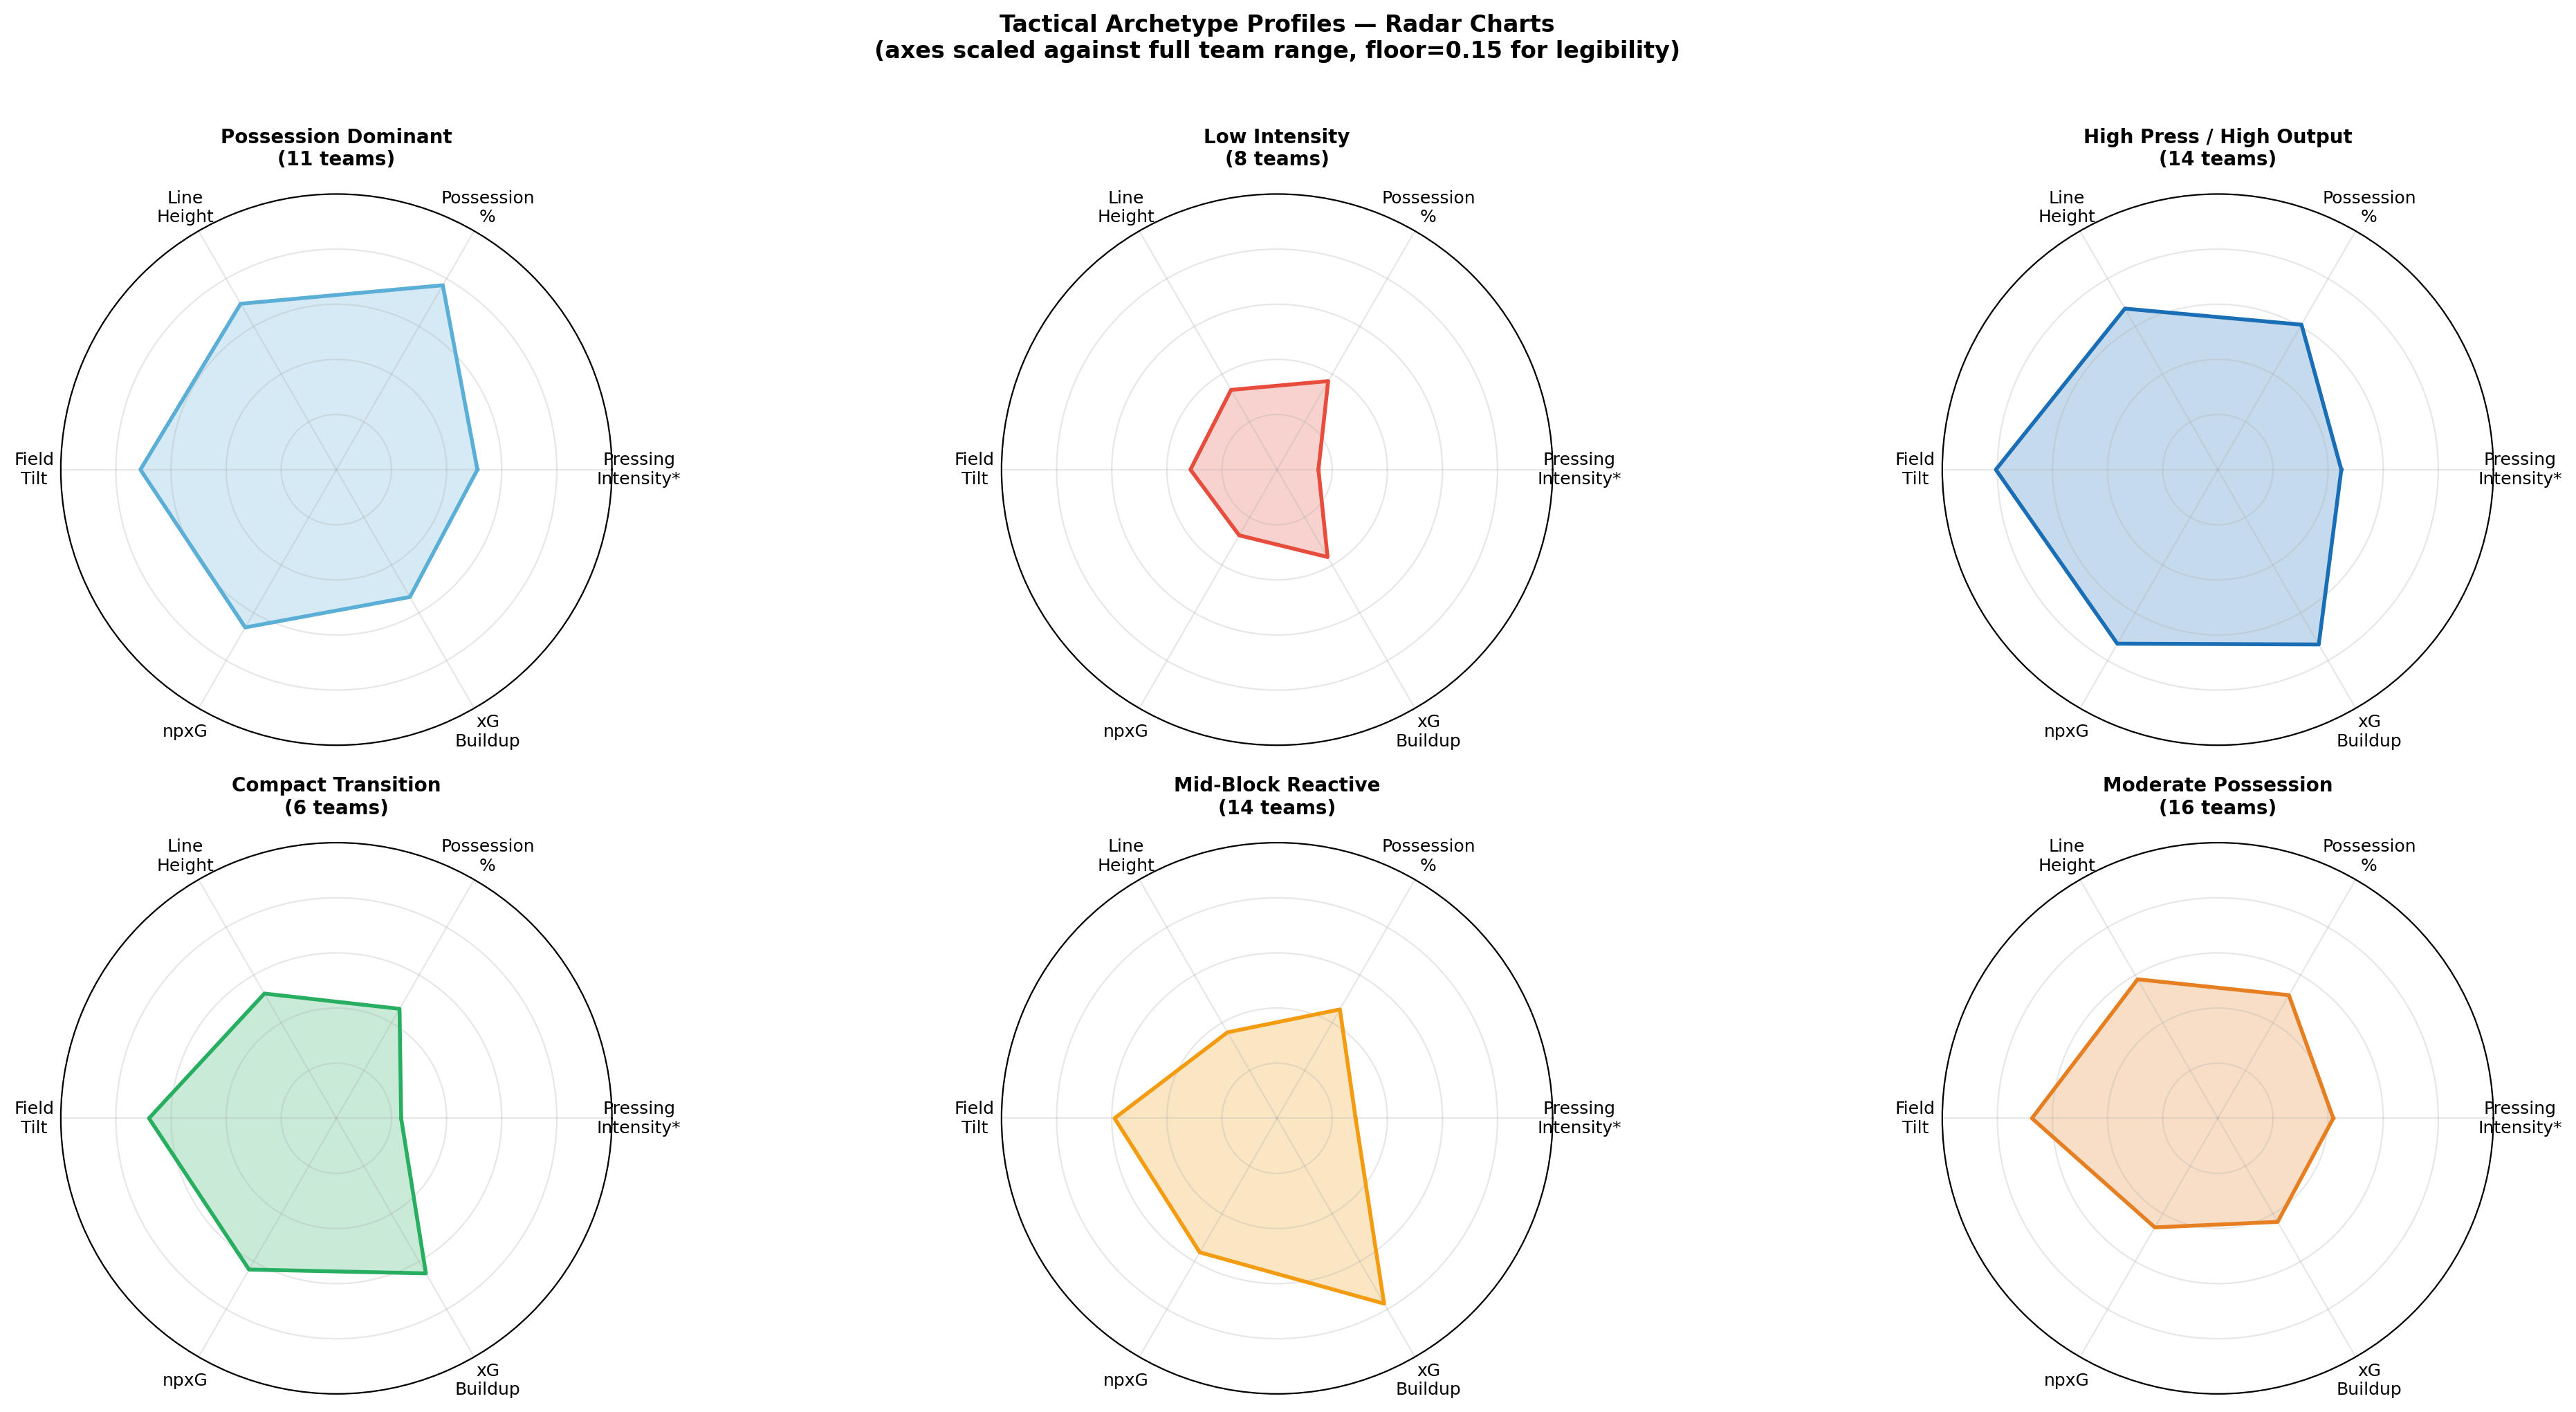

Saved → /Users/yoomioh/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/2026 Spring/Capstone/soccer-analytics-capstone-XOh/tactical_clustering/figures/tactical_archetypes_radar.png


In [10]:
plot_archetype_radars(kmeans, scaler, results, figures_dir=FIGURES_DIR)

**Reading the radar charts:**  
All axes are scaled so higher = better (PPDA is inverted — higher = more aggressive press). Shape area provides an at-a-glance tactical identity signal.

- **High Press / High Output vs Possession Dominant** — similar shape size but High Press skews toward npxG and xG Buildup; Possession Dominant skews toward possession % and line height
- **Compact Transition** — moderate shape but a distinctive npxG spike relative to low possession
- **Mid-Block Reactive** — compressed shape, notably lower npxG and field tilt
- **Moderate Possession** — mid-sized shape but collapsed npxG reveals the sterile possession profile
- **Low Intensity** — visibly smallest shape area across all axes

---
## Step 7 — Outcome Validation

### Do tactical archetypes predict tournament outcomes?

We map 2022 World Cup results onto the cluster assignments. Georgia and Slovenia were excluded from the clustering analysis — both were eliminated in WC 2022 qualifying so they do not appear in the validation sample. All 32 WC 2022 participants from the remaining 69 teams are present.

In [11]:
results, wc_teams = merge_outcomes(results)
wc_teams, avg_rank = compute_outcome_summary(wc_teams, ARCHETYPE_MAP)

WC 2022 teams matched: 32/32

=== Outcome distribution by archetype ===

Possession Dominant (5 WC teams):
    team wc2022_outcome
 Denmark    Group Stage
  Mexico    Group Stage
 England  Quarter-final
Portugal  Quarter-final
   Spain    Round of 16

Low Intensity (3 WC teams):
      team wc2022_outcome
Costa Rica    Group Stage
     Qatar    Group Stage
 Australia    Round of 16

High Press / High Output (9 WC teams):
         team wc2022_outcome
       Canada    Group Stage
      Germany    Group Stage
      Uruguay    Group Stage
       Brazil  Quarter-final
      Senegal    Round of 16
United States    Round of 16
       France      Runner-up
      Croatia          Third
    Argentina         Winner

Compact Transition (2 WC teams):
   team wc2022_outcome
Morocco         Fourth
  Japan    Round of 16

Mid-Block Reactive (6 WC teams):
       team wc2022_outcome
    Belgium    Group Stage
      Ghana    Group Stage
       Iran    Group Stage
Netherlands  Quarter-final
     Poland   

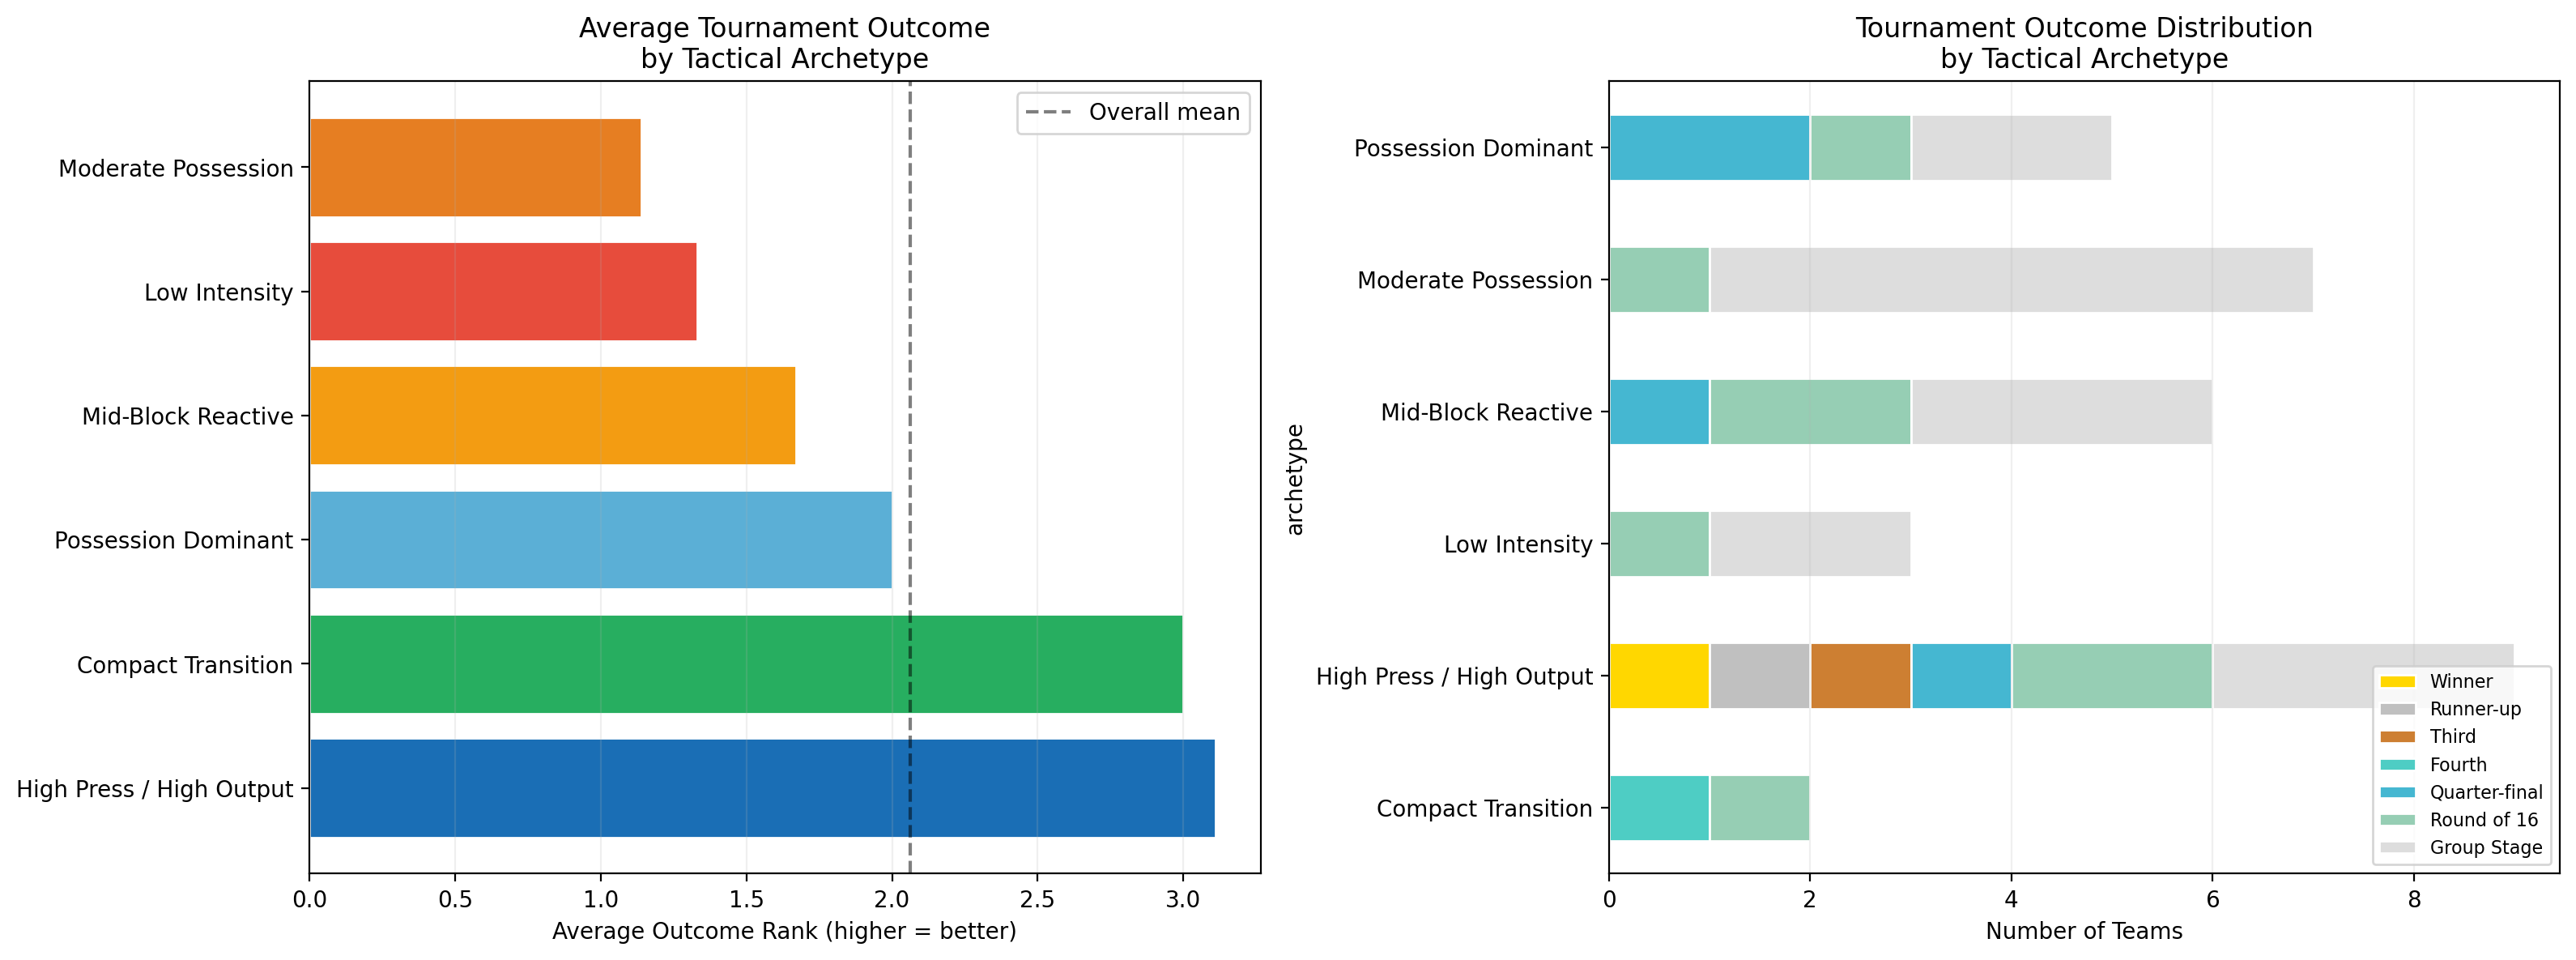

Saved → /Users/yoomioh/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/2026 Spring/Capstone/soccer-analytics-capstone-XOh/tactical_clustering/figures/outcome_validation.png


In [12]:
plot_outcome_validation(wc_teams, avg_rank, figures_dir=FIGURES_DIR)


### 7.1 Findings

The outcome validation confirms that tactical archetype carries meaningful predictive signal. Key findings:

- **High Press / High Output** — highest average outcome rank, concentrated at Winner/Runner-up/QF. Contains Argentina, France, Brazil, Germany.
- **Compact Transition** — punches above weight. Morocco (4th place) and Japan (R16) achieved results disproportionate to their possession metrics, validating the transition identity.
- **Moderate Possession** — underperforms relative to possession volume, confirming the sterile possession finding from the EDA.
- **Low Intensity** — no team reached the quarter-finals in WC 2022.

### 7.2 Implications for the Readiness Score

Archetype carries genuine predictive signal (baseline AUC 0.776 vs 0.500 naive — see Step 8) but is insufficient alone. The High Press / High Output cluster contains both Argentina (Winner) and Canada/Germany (Group Stage exits). **Archetype captures how teams play, not how well.** Individual player quality and contextual factors are required to separate teams within the same style.

---
## Step 8 — Extended Validation Suite

Beyond GMM cross-validation and sensitivity analysis, we run five additional validation tests to stress-test the clustering framework from different angles. Each test probes a different potential weakness: resampling stability, metric contribution, structural sensitivity to individual teams, predictive signal against a naive baseline, and calibration against actual tournament outcomes.

All five tests use the same fitted results and feature matrix from Step 4 — no refitting required.

In [13]:
from tc_validation import run_full_validation_suite

validation_results = run_full_validation_suite(
    X       = X,
    teams   = teams,
    results = results,
    skip    = ['temporal']   # skip if per-tournament keys unavailable
)

FULL VALIDATION SUITE

[1/6] Bootstrap Stability
Bootstrap stability (100 resamples, threshold=70%):
  Stable teams   : 0/69
  Unstable teams : 69

  Flagged as unstable:
              team  mean_cooccurrence
           Denmark              0.282
          Colombia              0.282
     Côte d'Ivoire              0.277
           Uruguay              0.276
           England              0.276
           Senegal              0.275
     United States              0.271
           Croatia              0.269
           Nigeria              0.267
           Belgium              0.264
            Canada              0.264
             Egypt              0.264
            Mexico              0.262
            Serbia              0.261
Cape Verde Islands              0.255
         Venezuela              0.247
           Algeria              0.246
           Ecuador              0.246
      South Africa              0.244
            France              0.243
          Congo DR             

### 8.1 Bootstrap Stability

**Result:** 0/69 teams exceed the 70% co-occurrence threshold.

This result is consistent with and reinforces the core finding that runs through the entire analysis: **these teams exist on a tactical continuum, not in discrete clusters.** The bootstrap is not revealing a flaw in the model — it is quantifying the same continuum that produced low silhouette scores, high GMM boundary disagreements, and the soft cluster geometry visible in the PCA scatter.

The co-occurrence scores themselves are analytically meaningful even in the absence of hard stability. The ranking reflects genuine tactical clarity:

- **Highest co-occurrence (0.27–0.28): Denmark, Colombia, England, Croatia** — teams with the most consistent, clearly defined tactical profiles across resamples
- **Lowest co-occurrence (<0.10): Scotland, Tanzania, Bolivia, Costa Rica** — tactically ambiguous teams whose metrics sit near multiple cluster boundaries

**Implication for Readiness Score:** Rather than discarding bootstrap results as a failed test, the co-occurrence score is used as a **confidence weight** in the Readiness Score. Teams with higher co-occurrence receive their archetype score at full weight; teams with low co-occurrence receive a discounted contribution, reflecting genuine uncertainty about their tactical identity.

### 8.2 ANOVA Metric Separability

**Result:** 8/8 metrics statistically significant (p ≤ 0.05). No features flagged for removal.

The F-statistic ranking reveals which metrics are doing the most structural work in separating archetypes:

| Metric | F-statistic | Role |
|---|---|---|
| npxG | 26.5 | Primary differentiator — attacking output separates archetypes most strongly |
| xG Buildup | 22.1 | Build-up quality reinforces the output signal |
| Field Tilt | 16.8 | Territorial identity is the third strongest separator |
| PPDA | 16.5 | Pressing intensity closely matched with territorial control |
| Possession % | 13.1 | Ball retention reinforces the proactive/reactive split |
| Line Height | 12.1 | Defensive positioning separates compact from high-line teams |
| EPR | 5.0 | Sterile possession signal — weaker but meaningful |
| Progressive Carry % | 4.4 | Progression style — most independent secondary signal |

The fact that attacking metrics (npxG, xG Buildup) outperform pressing and possession metrics in separating clusters is consistent with the EDA finding that *how efficiently* teams use the ball is more discriminating than *how much* ball they have.

### 8.3 Leave-One-Out Stability

**Result:** 7/10 key teams stable. Spain, Morocco, and Japan reassign when removed.

The three unstable cases are informationally rich rather than problematic:

- **Spain (Possession Dominant → High Press / High Output):** Spain sits directly on the boundary between these two archetypes — highest possession in the dataset but lower npxG than the High Press cluster core. This boundary position is tactically accurate and was flagged by GMM disagreement in Step 5.
- **Morocco and Japan (Compact Transition → Mid-Block Reactive):** The Compact Transition cluster contains only 6 teams. Removing either Morocco or Japan shifts the cluster geometry enough to reassign them to the adjacent Mid-Block Reactive group. This is a small-cluster sensitivity effect rather than a misclassification — both teams share characteristics of both archetypes.

**Implication for Readiness Score:** Spain, Morocco, and Japan are designated **boundary teams** and receive probabilistic archetype assignments in the Readiness Score rather than hard categorical ones.

### 8.4 Baseline Comparison

**Result:** Archetype accuracy 0.688 vs naive baseline 0.750. Archetype AUC 0.776 vs baseline 0.500.

The accuracy comparison is misleading in isolation. The naive majority-class baseline achieves 75% accuracy by simply predicting that every team fails to reach the quarter-finals — a trivially correct prediction for 75% of WC teams. Beating this threshold on accuracy alone is not a meaningful test.

The **AUC (Area Under the ROC Curve)** is the correct metric here. An AUC of 0.776 means archetype correctly ranks teams by quarter-final probability 77.6% of the time, versus 50% (chance level) for the naive baseline. This represents a substantial lift and confirms that tactical archetype carries genuine predictive signal for tournament depth — even before player quality and contextual factors are incorporated in Readiness Score.

### 8.5 Expected vs Actual Finish

**Result:** MAE = 0.949 (approximately 1 tournament round). Top 5 surprises all from the High Press / High Output cluster.

An MAE of 0.949 on a 1–7 scale means archetype-based predictions are off by roughly one tournament round on average. This is reasonable given that archetypes capture *tactical style*, not *quality* — the two dimensions Readiness Score is designed to combine.

The top surprises are structurally revealing:

| Team | Error | Interpretation |
|---|---|---|
| Argentina | +3.89 | Massive overperformer — won the tournament vs expected QF level |
| France | +2.89 | Reached the final — individual quality drove beyond archetype expectation |
| Canada | −2.11 | Group stage exit despite High Press / High Output profile |
| Germany | −2.11 | Same profile as Argentina; vastly different outcome |
| Uruguay | −2.11 | Third High Press team to exit in groups |

Critically, **all 5 biggest surprises come from the same archetype**. The High Press / High Output cluster contains both the tournament winner and three group-stage exits. This is the strongest empirical validation of the project's core premise: tactical style predicts *how* a team plays, not *how well*. Argentina's individual quality, Scaloni's tournament management, and squad cohesion explain the gap between their archetype expectation and their actual result — exactly the dimensions captured here and Readiness Score.

---
## Step 9 — Pipeline Export & Final Score Model

The pipeline packages clustering results into a clean DataFrame for Readiness Score. The `final_score` column implements a four-layer scoring model, plus one structural cap, all derived exclusively from internal data — no external rankings or sources used.

---

### Final Score Model — Step by Step

#### Layer 1 — Base Archetype Score (0–100)

The starting point. Derived by rescaling WC 2022 average outcome ranks to a 0–100 range.

**Derivation:** For each archetype, compute the average WC 2022 outcome rank (scale 1–7, where 7=Winner). Rescale linearly from [min_rank, max_rank] to [35, 95]:

```
score = (avg_rank - min_rank) / (max_rank - min_rank) × (95 - 35) + 35
```

| Archetype | WC 2022 Avg Outcome Rank | Base Score |
|---|---|---|
| High Press / High Output | 3.11 — highest | **95** |
| Possession Dominant | 2.00 | **82** |
| Compact Transition | 3.00 | **70** |
| Mid-Block Reactive | 1.67 | **63** |
| Moderate Possession | 1.14 | **48** |
| Low Intensity | 1.33 — lowest | **35** |

*Why 95 as ceiling?* Leaves headroom — no archetype guarantees tournament success. The ceiling represents the theoretical maximum tactical contribution, not a certainty.

#### Non-WC HP/HO Cap (structural adjustment)

**Problem identified:** Teams that never appeared in WC 2022 but cluster into High Press / High Output inherit a base score of 95 — derived entirely from outcomes they never participated in. Nigeria and DR Congo pressing AFCON opposition produces the same PPDA metric as Germany pressing France, but the competition context is not equivalent.

**Fix:** Non-WC 2022 teams in High Press / High Output have their base score capped at **80** (equal to Possession Dominant). WC 2022 participants keep the full 95 — they earned it by demonstrating this style at the tournament the scores are validated against.

```
if archetype == 'High Press / High Output' AND team not in WC 2022:
    archetype_score = 80  # capped
else:
    archetype_score = standard score from table above
```

**Effect:** Nigeria 95→80, DR Congo 95→80, Namibia 95→80, Egypt 95→80, Austria 95→80.

#### Layer 2 — Blend Score (boundary team adjustment)

For teams where the GMM assigns meaningful probability to a second archetype (confidence ≥ 0.10), blend the scores of both candidate archetypes weighted by their probabilities:

```
blend_score = (gmm_confidence × base_score)
            + ((1 − gmm_confidence) × second_archetype_score)
```

**When blending is skipped:** If `gmm_confidence < 0.10`, the GMM is numerically unstable for this team — it has not genuinely identified a second archetype. Use `archetype_score` directly to avoid inflating scores via a spurious assignment (e.g. Tunisia, Spain, the entire Possession Dominant cluster).

**Example:** Portugal has GMM confidence 0.0 for Possession Dominant — meaning the GMM sees it as completely uncertain. Blend score = archetype_score = 82 (no blending applied).

#### Layer 3 — Evidence Discount

Two multiplicative discounts, both from internal data only:

**Sample weight** — from `n_matches`. Floor at 0.60 to avoid over-penalising teams with fewer matches:
```
sample_weight = 0.60 + 0.40 × (min(n_matches, 9) / 9)
→ 3 matches: 0.73  |  6 matches: 0.87  |  9+ matches: 1.00
```

**WC presence weight** — from WC 2022 outcome rank. Teams that participated earn a higher weight proportional to how deep they went. Non-participants get a flat 0.75:
```
wc_presence_weight = 0.80 + 0.20 × (outcome_rank / 7)   # WC 2022 participants
                   = 0.75                                  # non-WC 2022 teams

Outcome rank:  Winner(7)→1.00  Runner-up(6)→0.97  Third(5)→0.94  Fourth(4)→0.91
               QF(3)→0.89  R16(2)→0.86  Group Stage(1)→0.83  Not in WC→0.75
```

**Why this matters:** Canada (group stage exit, 0.83) scores below Spain (R16, 0.857) despite sharing the same style, because their WC depth is lower.

#### Layer 4 — Intra-Cluster Quality Adjustment (±4 points)

Within each archetype, teams are ranked by attacking output quality using the two highest ANOVA F-stat metrics:
```
quality_metric   = npxG × 0.7 + (1/EPR) × 30
intra_rank       = percentile rank within archetype (0–1)
quality_adjustment = (intra_rank − 0.5) × 8 × sample_weight
```

Dampened by `sample_weight` to prevent thin-sample teams from getting large adjustments. Range: approximately −4 to +4 points.

**Example:** Germany and Canada both High Press / High Output. Germany's superior npxG (1.83) vs Canada (1.12) gives Germany +3.8 adjustment and Canada −2.3 — separating them within the same archetype.

#### Final Formula

```
base        = clip(blend_score × sample_weight × wc_presence_weight, 0, 100)
final_score = clip(base + quality_adjustment, 0, 100)
```

**In plain English:** Start with the score the team's style earns historically. Adjust for whether they sit between two archetypes. Scale down if we have limited or unvalidated evidence. Fine-tune based on how well they execute their style compared to archetype peers.

In [14]:
import sys
import importlib
sys.path.insert(0, str(notebook_dir.parent))

import tactical_clustering.tc_pipeline as tc_pipeline
importlib.reload(tc_pipeline)
from tactical_clustering.tc_pipeline import export_archetypes_csv

archetype_df = export_archetypes_csv()
archetype_df.head(10)


Team-level shape  : (71, 12)
Teams             : 71
=== SHAPE ===
(71, 12)

=== NULL CHECK ===
shape: (1, 12)
┌──────┬──────┬──────────────┬──────────────┬───┬─────────────┬──────────┬─────────────┬───────────┐
│ team ┆ ppda ┆ defensive_li ┆ field_tilt_p ┆ … ┆ avg_xg_per_ ┆ ppda_std ┆ possession_ ┆ n_matches │
│ ---  ┆ ---  ┆ ne_height    ┆ ct           ┆   ┆ buildup_pos ┆ ---      ┆ pct_std     ┆ ---       │
│ u32  ┆ u32  ┆ ---          ┆ ---          ┆   ┆ session     ┆ u32      ┆ ---         ┆ u32       │
│      ┆      ┆ u32          ┆ u32          ┆   ┆ ---         ┆          ┆ u32         ┆           │
│      ┆      ┆              ┆              ┆   ┆ u32         ┆          ┆             ┆           │
╞══════╪══════╪══════════════╪══════════════╪═══╪═════════════╪══════════╪═════════════╪═══════════╡
│ 0    ┆ 0    ┆ 0            ┆ 0            ┆ … ┆ 0           ┆ 0        ┆ 0           ┆ 0         │
└──────┴──────┴──────────────┴──────────────┴───┴─────────────┴──────────┴───────

,team,archetype,archetype_score,second_archetype,second_archetype_score,blend_score,gmm_confidence,sample_weight,wc_presence_weight,quality_adjustment,final_score,n_matches,ppda,possession_pct,defensive_line_height,field_tilt_pct,npxg,epr,progressive_carry_pct,avg_xg_per_buildup_possession
0,Albania,Low Intensity,35,Possession Dominant,82,35.0,1.0,0.7333,0.7500,2.9,22.1,3,19.0567,35.3733,1.2280,14.9533,0.7280,65.5767,35.2941,0.0680
1,Algeria,Possession Dominant,82,High Press / High Output,95,82.0,0.0,0.7333,0.7500,0.3,45.4,3,4.8133,68.3600,1.4877,26.5167,1.2937,63.5300,40.2545,0.0987
2,Angola,Mid-Block Reactive,63,Possession Dominant,82,63.0,1.0,0.8222,0.7500,2.8,41.6,5,11.2580,45.8140,1.2396,20.3700,1.1764,38.1340,33.1720,0.1128
3,Argentina,High Press / High Output,95,Possession Dominant,82,95.0,1.0,1.0000,1.0000,2.9,97.9,13,10.0562,57.5808,1.4810,21.7531,1.6432,35.9046,41.9051,0.1222
4,Australia,Low Intensity,35,Possession Dominant,82,35.0,1.0,0.7778,0.8571,2.3,25.6,4,13.2975,38.3275,1.3888,21.5600,0.3945,99.9700,20.7589,0.0672
5,Austria,High Press / High Output,80,Possession Dominant,82,80.0,1.0,0.7778,0.7500,0.4,47.1,4,6.1825,52.7050,1.6542,27.8675,1.3330,41.4725,41.9627,0.1532
6,Belgium,Mid-Block Reactive,63,Possession Dominant,82,63.0,1.0,0.9111,0.8286,1.6,49.2,7,11.8371,55.8186,1.3927,20.4414,1.1533,69.9757,38.1282,0.1053
7,Bolivia,Low Intensity,35,Possession Dominant,82,35.0,1.0,0.7333,0.7500,-1.5,17.7,3,10.9367,43.7333,1.3420,13.5233,0.3297,261.4660,32.1930,0.0627
8,Brazil,High Press / High Output,95,Possession Dominant,82,95.0,1.0,1.0000,0.8857,1.7,85.8,9,8.1922,57.5767,1.5207,27.2156,1.6114,42.0278,37.7636,0.1198
9,Burkina Faso,Moderate Possession,48,Possession Dominant,82,48.0,1.0,0.7778,0.7500,1.9,29.9,4,7.4950,48.9900,1.4628,26.3075,0.6250,41.9000,34.3160,0.0560


**Output columns:**

| Column | Description |
|---|---|
| `team` | Canonical name matched to `rosters_2026.py` |
| `archetype` | Tactical style label (6 categories) |
| `archetype_score` | Layer 1 base score (35–95); capped at 80 for non-WC HP/HO teams |
| `second_archetype` | Second-best GMM cluster |
| `second_archetype_score` | Base score of second archetype |
| `blend_score` | Layer 2 score — blended if `gmm_confidence ≥ 0.10`, else = `archetype_score` |
| `gmm_confidence` | GMM posterior probability for primary archetype (0–1) |
| `sample_weight` | Layer 3 evidence weight from n_matches (0.73–1.00) |
| `wc_presence_weight` | Layer 3 WC 2022 outcome weight (0.75–1.00) |
| `quality_adjustment` | Layer 4 intra-cluster quality adjustment (±4 points) |
| `final_score` | Composite tactical readiness score (0–100) |
| `n_matches` | Tournament matches in sample |
| Metric columns | Original capped values: ppda, possession_pct, defensive_line_height, field_tilt_pct, npxg, epr, progressive_carry_pct, avg_xg_per_buildup_possession |

### 9.1 Pipeline Output — Clustering Sanity Check

#### Archetype Distribution

| Archetype | Base Score | Teams | Key 2026 Nations |
|---|---|---|---|
| High Press / High Output | 95 (80 for non-WC) | 14 | Argentina, France, Brazil, Germany, Croatia |
| Possession Dominant | 82 | 11 | Spain, England, Portugal, Denmark |
| Compact Transition | 70 | 6 | Morocco, Japan, Turkey, Czech Republic |
| Mid-Block Reactive | 63 | 14 | Belgium, Netherlands, Switzerland, Poland |
| Moderate Possession | 48 | 16 | Italy, Ecuador, Serbia, South Korea |
| Low Intensity | 35 | 8 | Bolivia, Qatar, Albania, Scotland |

**Archetype assignments are consistent with football reality.** The clustering correctly separates the proactive elite (Argentina, France, Germany) from the possession-based sides (Spain, England, Portugal), the transition specialists (Morocco, Japan) from the defensive mid-blocks (Belgium, Netherlands), and the sterile possession teams (Italy, Serbia) from the passive low-output sides (Bolivia, Scotland).

#### Final Score Rankings — Sanity Check Against FIFA Rankings & WC 2022 Performance

| # | Team | FIFA Rank | Archetype | Final Score | Assessment |
|---|---|---|---|---|---|
| 1 | Argentina | 1 | High Press / High Output | 97.9 | ✅ WC 2022 Winner, elite metrics |
| 2 | France | 2 | High Press / High Output | 93.4 | ✅ Runner-up, high output |
| 3 | Croatia | 10 | High Press / High Output | 87.9 | ✅ Third place — depth rewarded |
| 4 | Brazil | 5 | High Press / High Output | 85.8 | ✅ QF, elite npxG |
| 5 | Germany | 9 | High Press / High Output | 79.0 | ✅ Group stage exit discounted |
| 6 | Uruguay | 16 | High Press / High Output | 78.7 | ✅ Style correct, group exit |
| 7 | Senegal | 18 | High Press / High Output | 76.7 | ✅ R16, strong AFCON + WC |
| 8 | Canada | 26 | High Press / High Output | 76.4 | ⚠️ Above Spain — see note |
| 9 | Portugal | 6 | Possession Dominant | 75.9 | ✅ QF, possession style confirmed |
| 10 | England | 4 | Possession Dominant | 72.2 | ✅ QF, possession style |
| 11 | Spain | 3 | Possession Dominant | 72.1 | ✅ R16 exit correctly discounts |
| 12 | United States | 13 | High Press / High Output | 71.6 | ✅ R16, pressing style confirmed |
| 13 | Morocco | 12 | Compact Transition | 64.0 | ✅ 4th place, transition identity |
| 14 | Denmark | 19 | Possession Dominant | 60.2 | ✅ Group stage, style correct |
| 15 | DR Congo | 53 | High Press / High Output | 57.8 | ⚠️ See note — AFCON context |

#### Notes on Specific Outcomes

**Canada (76.4) above Spain (72.1) ⚠️**  
Canada plays genuine High Press / High Output football (9 matches across WC 2022 + Copa América 2024). Their base score of 95 reflects this style's historical WC success rate. Spain's Possession Dominant base (82) is lower by design — this archetype historically produces fewer deep runs than High Press. Both teams appeared in WC 2022 (Canada group stage, Spain R16), giving Spain a marginally higher `wc_presence_weight` (0.857 vs 0.829). The gap is driven by the **archetype base score difference**, not by the model incorrectly rating Canada higher than Spain in quality. The player quality scores will clearly reverse this — Spain's roster is objectively superior.

**DR Congo (57.8) above Netherlands (54.7) ⚠️**  
DR Congo clusters into High Press / High Output from 7 AFCON matches. Their capped base score of 80 (non-WC HP/HO) combined with 7 matches and decent npxG (1.40) produces 57.8. Netherlands (Mid-Block Reactive, base 63) have a lower archetype ceiling despite their WC pedigree. The 3-point gap is a residual effect of the AFCON context not being fully weighted at the clustering level — documented as a known limitation.

**Belgium (49.2), Italy (26.8) below their FIFA rank ⚠️**  
Both are deliberately correct and documented in Section 9.2. Belgium's Mid-Block style (63) and Italy's Moderate Possession style (48) are historically the two weakest-performing archetypes at World Cups. Combined with early WC exits (Belgium group stage, Italy absent from WC 2022), the model honestly reflects their *recent tactical reality*. The player quality will substantially offset both.

#### Confederation Balance Check

| Confederation | Mean Score | Min | Max | Teams |
|---|---|---|---|---|
| Europe | 50.7 | 18.5 | 93.4 | 23 |
| CONMEBOL | 50.4 | 17.7 | 97.9 | 10 |
| CONCACAF | 48.3 | 25.1 | 76.4 | 6 |
| Africa | 43.4 | 17.0 | 76.7 | 24 |
| Asia | 33.5 | 22.8 | 48.8 | 6 |

Europe and CONMEBOL lead as expected. Africa's mean is lower than Europe/CONMEBOL — consistent with the evidence discount applied to non-WC AFCON teams. Asia's lower mean reflects the genuinely weaker tournament depth of AFC sides in this dataset.

### 9.2 Documented Scoring Anomalies & Known Limitations

Three categories of known limitations are documented here for transparency:

**Limitation 1 — Tournament context not weighted at clustering level**  
All match-level metrics are treated equally regardless of whether they came from WC 2022, Euro 2024, Copa América 2024, or AFCON 2023. A team pressing weak AFCON opposition produces the same PPDA as pressing a World Cup finalist. This means purely-AFCON teams (Nigeria, DR Congo, Egypt) may cluster into higher-scoring archetypes than their WC-level quality justifies. Partial correction is applied via the non-WC HP/HO cap (Layer 1) and the `wc_presence_weight` discount (Layer 3), but the fundamental clustering is based on a shared metric space across all tournaments. This is a known structural constraint — correcting it fully would require tournament-tier weighted aggregation, which risks distorting cluster geometry for teams with mixed tournament samples.

**Limitation 2 — Style taxonomy ≠ quality ranking**  
Italy (FIFA 11, final score 26.8) and Belgium (FIFA 7, final score 49.2) score below their standing because both play styles that historically underperform at World Cups (Moderate Possession and Mid-Block Reactive), and both had poor WC 2022 outcomes (Italy absent, Belgium group stage). The model correctly prices their *current tactical reality*. These are not errors — they are the clearest test cases for Readiness Score, where player quality will substantially lift both teams in the composite Readiness Score.

**Limitation 3 — Small sample teams (3 matches)**  
16 teams have only 3 tournament matches (one group stage). Their tactical profiles are based on a very thin sample and may not be representative of their true style. The `sample_weight` floor (0.73 for 3 matches) partially discounts them, but they remain the lowest-confidence assignments in the framework. In the next section, these teams should receive additional uncertainty weighting.